# Required Functions

In [159]:
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
#from matplotlib.pyplot import pie,axis,show
#%matplotlib inline

In [160]:
import pandas as pd
import json
import re
def load_dataframe(filename):
    with open(filename,'r') as f:
        df = pd.DataFrame(json.load(f))
        df['index'] = range(len(df))
        return df

def drop_cols(df,dropcols):
    return df[list(filter(lambda x:not re.search('|'.join(dropcols),x) ,df.columns))]

def plot_pie_chart(df,dropcols,dropre=['min','max','avg'],index=0,ax_elem=None):
    if ax_elem is None:
        print('ERROR: pass an axis element')
        return
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    dfi = df.loc[str(index),:]
    ax_elem.axis('equal')
    labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
    ax_elem.pie(dfi, labels=labels,startangle=0)
    
# def plot_pie_chart(df,dropcols,dropre=['min','max','avg'],index=0):
#     df = df.drop(dropcols,axis=1)
#     df = drop_cols(df,dropre)
#     dfi = df.loc[str(index),:]
#     axis('equal')
#     labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
#     pie(dfi, labels=labels,startangle=0)
#     show()
        
# def plot_pie_charts(df,dropcols,dropre=['min','max','avg'],count=None):
#     df = df.drop(dropcols,axis=1)
#     df = drop_cols(df,dropre)
#     count = len(df) if count is None else count
#     for i in range(count):
#         dfi = df.loc[str(i),:]
#         axis('equal')
#         labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
#         pie(dfi, labels=labels,startangle=0)
#         show()

# def plot_pie_chart_(df,dropcols,dropre=['min','max','avg'],count=None,figdim=10):
#     df = df.drop(dropcols,axis=1)
#     df = drop_cols(df,dropre)
#     count = len(df) if count is None else count
#     rows = max(int(count/2),1)
#     cols = 2 if count>1 else 1
#     figsize = tuple([ figdim*rows for _ in range(rows) ])
#     fig, ax = plt.subplots(rows,cols,figsize=figsize)
        
#     for i in range(count):
#         dfi = df.loc[str(i),:]
#         ax = fig.add_subplot(rows,cols,(i%cols)+1)
#         labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
#         _, _ = ax.pie(dft.loc['0',:], startangle=0,labels=labels)
#         ax.axis('equal')

def list_detections(output):
    dets_d = {}
    for ko in output.keys():
        d = output[ko]
        dets = []
        for k in d.keys():
            dc = d[k]
            dets.append(dc['output']['labels_detected'])
        dets_d[ko]=dets
    return dets_d

def count_elems(dct):
    count = {}
    sums = {}
    for k in dct.keys():
        count[k] = list(map(lambda l:len(l) ,dct[k]))
        sums[k] = sum(count[k])
    return count,sums

def read_dict(jsonfile):
    op = {}
    with open(jsonfile,'r') as f:
        op = json.load(f)
    return op

def round_cols(df,cols,digits=4):
    df.loc[:,cols] = round(df.loc[:,cols],digits)
    return df

def get_intervals_data():
    its = list(map(read_dict,intervals_dicts))
    return its

def get_info_what_key(dct,key):
    for i in dct.keys():
        d = dct[i]
        for k in d.keys():
            if d[k]['key']==key:
                return k

def get_int_info(dct):
    res = {}
    for i in dct.keys():
        d = dct[i]
        res[i]={}
        for k in d.keys():
            key = d[k]['key']
            res[i][key]=[d[k]['info'],d[k]['success']]
            #res[i][key]['what']=k
    return res

def info_det(dct):
    res = {}
    for i in dct.keys():
        res[i] = dct[i]['detect']
    return res

def merge_intervals_info(detector_intervals):
    rj = {}
    for k in dts[1].keys():
        d = dts[1][k]
        rj[k]={'post_detection_ops':d['post_detection_ops'][0],'success':d['post_detection_ops'][1],'detect':d['detect'][0]}
    return rj

def cpy_det_sucess_data(detector_intervals_merged,ints_dm):
    for k in ints_dm.keys():
        ints_dm[k][1] = detector_intervals_merged[k]['success']
    return ints_dm

In [161]:
def plot_data_for_file(data_ex,ints_ex,ints_dm,file_index = 0):
    file_index = str(file_index)
    print('Plotting data for performance of',data_ex.loc[file_index]['name'],'on',data_ex.loc[file_index]['input_file'])
    fig, axes = plt.subplots(2,2,figsize=(20,20))
    pie_ax,lax,oax1,oax2=axes.reshape(-1,1)
    plt.subplots_adjust(wspace=0.4)
    plt.close(fig)
    pie_ax = pie_ax[0];oax1 = oax1[0];oax2 = oax2[0];lax=lax[0];
    
    df = pd.DataFrame()
    det_count = ints_dm[file_index][1]
    time_taken_per_frame_ex = ints_ex[file_index][0]
    time_taken_per_frame_dm = ints_dm[file_index][0]
    
    #pie chart
    plot_pie_chart(data_ex,['name','index','input_file','Total_time','video_duration','video_file_size'],index=file_index,ax_elem=pie_ax)
    
    #contour X(det count) vs time taken(multiple Y) for dm_detect and ex_detect
    df = pd.DataFrame()
    df['number of detections'] = det_count
    df['time taken per frame - detector model'] = time_taken_per_frame_dm
    df['time taken per frame - overall'] = time_taken_per_frame_ex
    #sns.jointplot("number of detections", "time taken per frame - detector model", data=df, height=5, ratio=6, color="black", kind="kde", space=0,shade=True)
    sns.lineplot(x="number of detections",y= "time taken per frame - detector model", data=df,ax=oax1)
    sns.lineplot(x="number of detections",y= "time taken per frame - overall", data=df,ax=oax2)
    #running X (ith frame) , det count, time_dm,time_ex,
    dfdm = pd.DataFrame()
    dfdm['number of detections'] = det_count
    dfdm['time taken per frame'] = time_taken_per_frame_dm
    dfdm['type'] = 'detector model'
    dfdm['frame'] = list(range(len(dfdm)))
    dfex = pd.DataFrame()
    dfex['number of detections'] = det_count
    dfex['time taken per frame'] = time_taken_per_frame_ex
    dfex['type'] = 'overall'
    dfex['frame'] = list(range(len(dfex)))
    df = dfdm.append(dfex)
    sns.lineplot(x="frame",y="time taken per frame",style="type", data=df,ax=lax)
    return fig

# Fetch & Load Data

In [162]:
df_files = ['detection_model-time.json','extractor-time.json']
output_data_dict_file = 'output_data.json' 
intervals_dicts = ['ext-intervals_data.json','det-intervals_data.json']

In [163]:
drop_columns = False
drop_re=['min','max'] #drop all columns that have these words
cols_to_round = ['video_duration','detect-avg']

dfs = list(map(load_dataframe,df_files))
if drop_columns:
    dfs = list(map(lambda d:drop_cols(d,drop_re),dfs))

dfs = list(map(lambda d:round_cols(d,cols_to_round),dfs))
data_dm,data_ex = dfs 
#dfex - DataFrame of extractor (main program)
#dfdm - DataFrame of Detector model
output_dict = read_dict(output_data_dict_file)
#detections_lst = list_detections(output_dict)


#detections_count, detections_sum = count_elems(detections_lst)

dts = list(map(get_int_info,get_intervals_data()))
ints_ex,ints_dm = list(map(info_det,dts)) #intervals data
detector_intervals_merged = merge_intervals_info(dts[1])
ints_dm = cpy_det_sucess_data(detector_intervals_merged,ints_dm)


#important takeaways:
#ints_dm and ints_ex, detections_count, data_dm,data_ex

# Inspect Data

In [164]:
print(data_ex.columns,'\n',data_dm.columns)

Index(['Total_time', 'download_video', 'detect-avg', 'name', 'input_file',
       'fetch_frame-max', 'fetch_frame-total', 'load_video_file', 'load_model',
       'detect-max', 'detect-total', 'init&prepare_model', 'fetch_frame-min',
       'save_annotations', 'fetch_frame-avg', 'detect-min', 'video_duration',
       'video_file_size', 'index'],
      dtype='object') 
 Index(['detect-avg', 'name', 'post_detection_ops-total', 'input_file',
       'post_detection_ops-max', 'post_detection_ops-min',
       'post_detection_ops-avg', 'load_model', 'detect-max', 'import_deps',
       'detect-total', 'init_model', 'video_duration', 'detect-min',
       'video_file_size', 'index'],
      dtype='object')


## DataFrame from extractor (main program)

In [165]:
data_ex #DataFrame of extractor (main program)

,Total_time,download_video,detect-avg,name,input_file,fetch_frame-max,fetch_frame-total,load_video_file,load_model,detect-max,detect-total,init&prepare_model,fetch_frame-min,save_annotations,fetch_frame-avg,detect-min,video_duration,video_file_size,index
0,17.0337,2.0436,0.2923,yolo,Cristiano Ronaldo Goals where Goalkeepers Dont...,0.2759,2.3160,0.0123,7.9751,0.3214,4.0922,0.1007,0.0430,0.4186,0.1654,0.2646,292.4800,43.0,0
1,11.9431,1.5148,0.2758,yolo,Lane detection and object detection with OpenC...,0.2236,0.8640,0.0062,7.6340,0.3073,1.3790,0.1056,0.1428,0.3163,0.1728,0.2616,108.3750,17.0,1
2,15.1799,1.9922,0.2665,yolo,Smart & intelligent Defenders 2019 🧠 Art Of D...,0.2396,1.7079,0.0121,7.3565,0.2840,3.4639,0.0935,0.0914,0.3773,0.1314,0.2606,272.0333,40.0,2
3,12.6998,1.6472,0.2717,yolo,Yuvi 6 sixes full HD.mp4,0.1701,0.8042,0.0082,7.4409,0.2883,2.1732,0.0965,0.0435,0.3452,0.1005,0.2630,171.8800,20.0,3


## DataFrame from Detector model

In [166]:
data_dm #DataFrame of Detector model

,detect-avg,name,post_detection_ops-total,input_file,post_detection_ops-max,post_detection_ops-min,post_detection_ops-avg,load_model,detect-max,import_deps,detect-total,init_model,video_duration,detect-min,video_file_size,index
0,0.0296,yolo,0.6271,Cristiano Ronaldo Goals where Goalkeepers Dont...,0.0483,0.0402,0.0448,7.9663,0.0306,0.0786,0.4137,0.0213,292.4800,0.0282,43.0,0
1,0.0290,yolo,0.2171,Lane detection and object detection with OpenC...,0.0449,0.0416,0.0434,7.6267,0.0307,0.0836,0.1448,0.0213,108.3750,0.0283,17.0,1
2,0.0288,yolo,0.5364,Smart & intelligent Defenders 2019 🧠 Art Of D...,0.0441,0.0394,0.0413,7.3494,0.0293,0.0783,0.3739,0.0147,272.0333,0.0282,40.0,2
3,0.0290,yolo,0.3357,Yuvi 6 sixes full HD.mp4,0.0436,0.0409,0.0420,7.4327,0.0302,0.0783,0.2322,0.0176,171.8800,0.0285,20.0,3


# Plot Data

Plotting data for performance of yolo on Cristiano Ronaldo Goals where Goalkeepers Dont Move.mp4


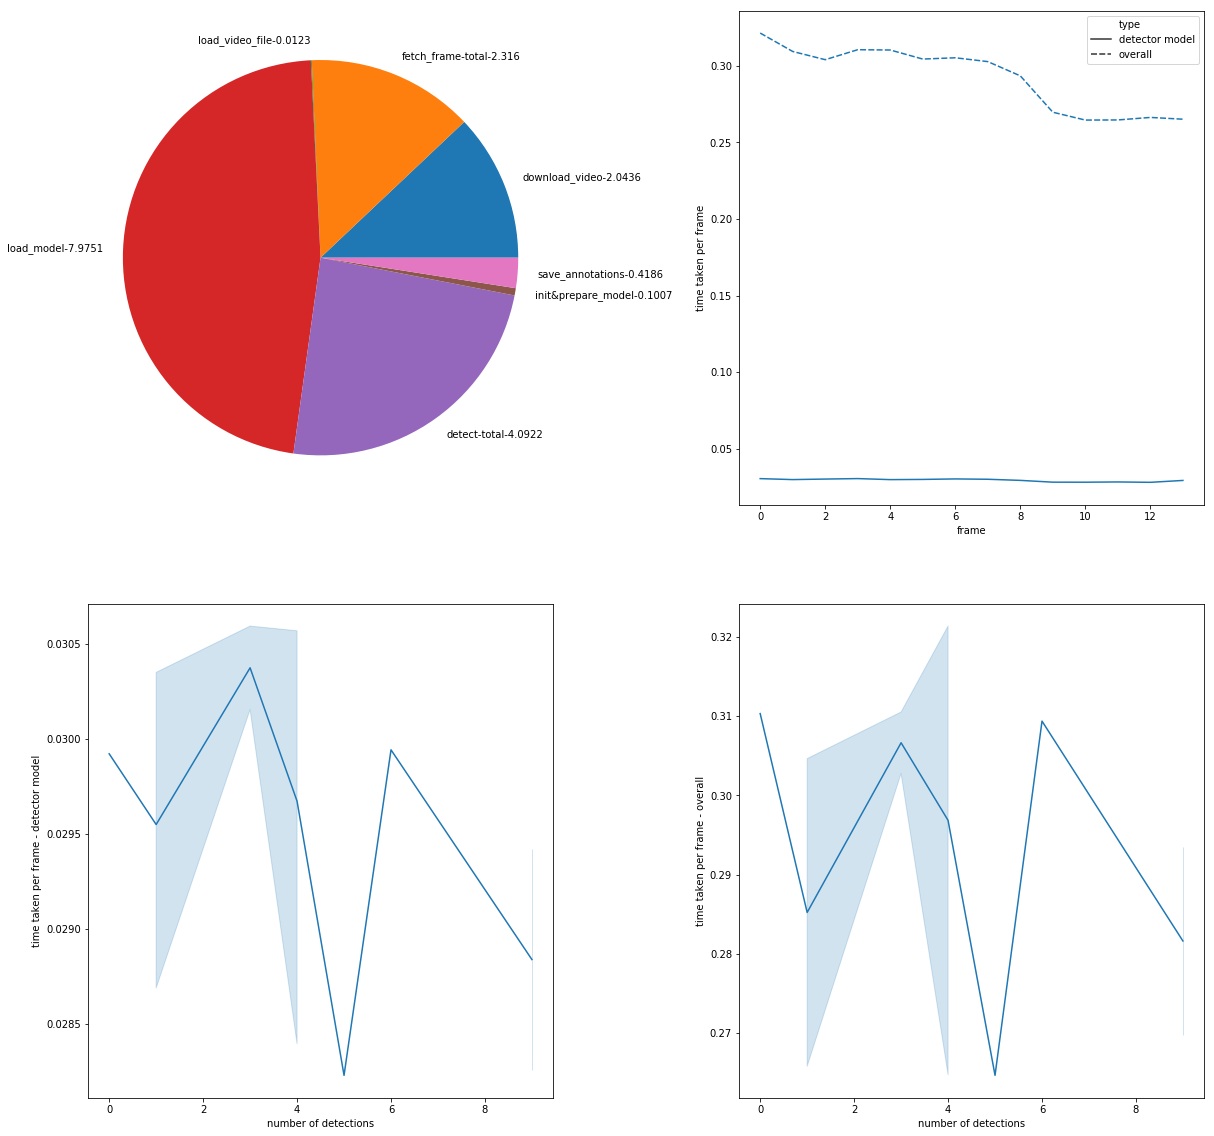

In [167]:
plot_data_for_file(data_ex,ints_ex,ints_dm,file_index = 0)

# Other metrics

In [183]:
print('Index ','\t Filename')
for i in range(len(data_ex)):
    print(data_ex.loc[str(i),'index'],'\t',data_ex.loc[str(i),'input_file'])

Index  	 Filename
0 	 Cristiano Ronaldo Goals where Goalkeepers Dont Move.mp4
1 	 Lane detection and object detection with OpenCV & TensorFlow.mp4
2 	 Smart & intelligent Defenders 2019  🧠 Art Of Defence 💡.mp4
3 	 Yuvi 6 sixes full HD.mp4


Text(0.5, 1.0, 'Detection time inside detector model vs video duration')

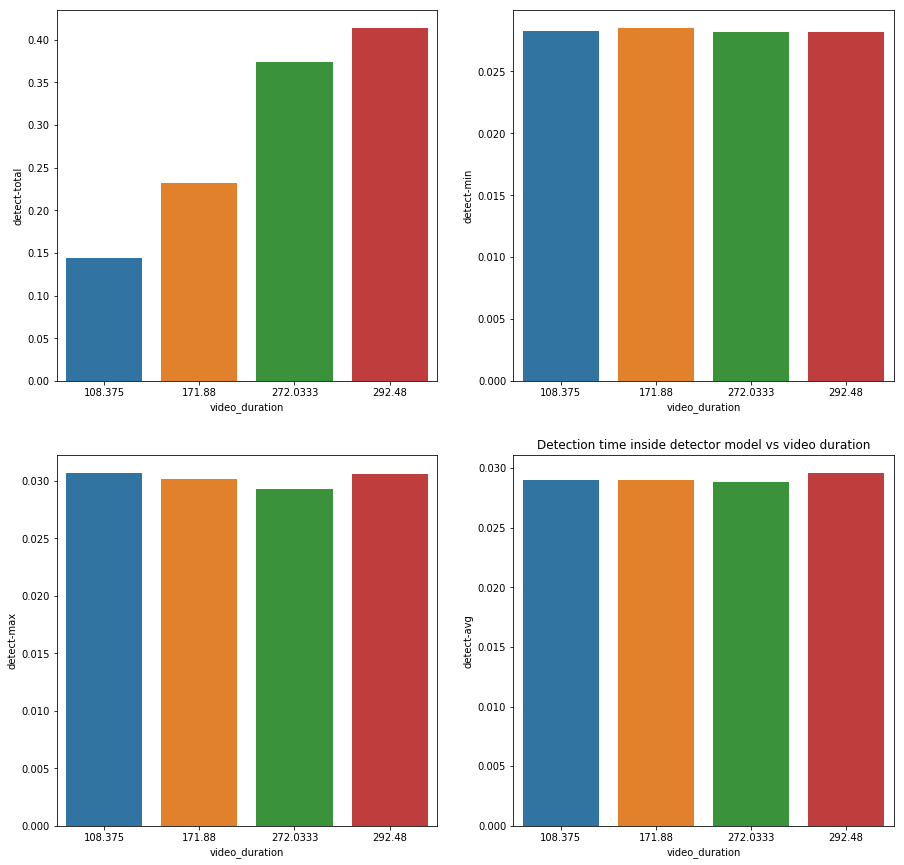

In [184]:
fig, axes = plt.subplots(2,2,figsize=(15,15))
xmetric = ['video_duration','index'][0]
dft = data_dm
sns.barplot(data=dft,x=xmetric,y='detect-total',ax=axes[0,0])
sns.barplot(data=dft,x=xmetric,y='detect-min',ax=axes[0,1])
sns.barplot(data=dft,x=xmetric,y='detect-max',ax=axes[1,0])
sns.barplot(data=dft,x=xmetric,y='detect-avg',ax=axes[1,1])

plt.title('Detection time inside detector model vs video duration')
#plt.legend(title='Video file name', loc='lower right', labels=data_ex.loc[:,'input_file'])